# Week 1 — Supplement: Extra Topics & Slide Guide

**Course:** ML, Deep Learning & Computer Vision  
**Use with:** `Week_01_Python_NumPy_Pandas_Visualisation.ipynb` (the main notebook)  

---

This notebook contains **additional material** not covered in the main Week 1 notebook:  
- Slide references and 2-hour pacing for each class  
- f-strings and string methods  
- Error handling (`try`/`except`)  
- NumPy dtypes and memory  
- Views vs copies (common bug source)  
- Broadcasting rules deep-dive with `keepdims`  
- `.loc` vs `.iloc` (the right way to select in Pandas)  
- Loading CSVs with `pd.read_csv` options  
- `.apply()`, `.map()`, and `pd.cut()`  
- Choosing the right chart type  

**Work through the main notebook first**, then use this supplement to fill in the gaps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_style("whitegrid")
np.random.seed(42)

---
## Class 1 — Pacing guide (2 hours)

**Companion slides:** `Class_01_Python_NumPy_Slides.pptx`  
**Main notebook:** sections 1.1–1.7 (Python), 2.1–2.6 (NumPy)

| Time | Topic | Slides | Main notebook |
|------|-------|--------|---------------|
| 0:00–0:30 | Python crash course | Slides 3–6 | §1.1–1.7 |
| 0:30–1:00 | NumPy fundamentals | Slides 7–9 | §2.1–2.5 |
| 1:00–1:25 | Broadcasting & vectorisation | Slides 10–14 | §2.3, 2.6 |
| 1:25–1:50 | Hands-on exercises | Slide 15 | Exercises 1–4 |
| 1:50–2:00 | Wrap-up & key takeaways | Slide 16 | — |

The sections below cover topics **not in the main notebook** — insert them at the indicated points.

---
## Python extras (insert after §1.1 in main notebook)

### f-strings — formatting patterns for ML logging

F-strings (Python 3.6+) are everywhere in ML code for printing training progress, metrics, and results.

In [2]:
model = "ResNet"
accuracy = 0.9247
epoch = 42

# Formatting patterns you'll use daily
print(f"Epoch {epoch}: accuracy = {accuracy:.2f}")      # 2 decimal places
print(f"Epoch {epoch:04d}: accuracy = {accuracy:.4f}")  # zero-padded int, 4 decimals
print(f"Epoch {epoch}: accuracy = {accuracy:.1%}")      # as percentage: 92.5%
print(f"Model: {model!r}")                              # with quotes: 'ResNet'

# Useful string methods for file handling
path = "  /data/train/img_001.JPG  "
print(path.strip())           # remove whitespace
print(path.strip().lower())   # lowercase
print(path.strip().lower().endswith(('.jpg', '.png', '.jpeg')))  # True

# Joining paths
import os
data_dir = "/data/train"
filename = "img_001.jpg"
print(os.path.join(data_dir, filename))  # platform-safe path joining

Epoch 42: accuracy = 0.92
Epoch 0042: accuracy = 0.9247
Epoch 42: accuracy = 92.5%
Model: 'ResNet'
/data/train/img_001.JPG
/data/train/img_001.jpg
True
/data/train/img_001.jpg


### Error handling — keeping your training loop alive

In ML, errors happen constantly: files not found, shape mismatches, NaN values.  
`try/except` keeps your training loop running. Insert this after §1.5 (Functions) in the main notebook.

In [3]:
# Basic try/except
def safe_divide(a, b):
    try:
        return a / b
    except ZeroDivisionError:
        print("Warning: division by zero, returning 0")
        return 0

print(safe_divide(10, 3))   # 3.333
print(safe_divide(10, 0))   # Warning... 0

# Real ML pattern: loading files that might not exist
import os
def load_data(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found: {path}")
    print(f"Loading {path}...")

try:
    load_data("/nonexistent/data.csv")
except FileNotFoundError as e:
    print(f"Caught error: {e}")

# Pattern: try multiple file paths
def find_dataset(*paths):
    for p in paths:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Dataset not found in any of: {paths}")

# try:
#     path = find_dataset("/kaggle/input/data.csv", "data/data.csv", "../data.csv")
# except FileNotFoundError:
#     print("Please download the dataset.")

3.3333333333333335
0
Caught error: Dataset not found: /nonexistent/data.csv


---
## NumPy extras (insert after §2.1 in main notebook)

### dtypes — why they matter in ML

NumPy arrays have a single dtype. In deep learning, dtype affects memory, speed, and GPU compatibility.

In [4]:
# Default is float64 (double precision)
a = np.array([1.0, 2.0, 3.0])
print(f"Default:  dtype={a.dtype}, itemsize={a.itemsize} bytes")

# float32 — what GPUs prefer
a32 = np.array([1.0, 2.0, 3.0], dtype=np.float32)
print(f"float32:  dtype={a32.dtype}, itemsize={a32.itemsize} bytes")

# float16 — for inference on mobile/edge
a16 = a.astype(np.float16)
print(f"float16:  dtype={a16.dtype}, itemsize={a16.itemsize} bytes")

# Memory comparison for a large array (10M elements)
big = np.random.randn(10000, 1000)
print(f"\nfloat64: {big.nbytes / 1e6:.0f} MB")
print(f"float32: {big.astype(np.float32).nbytes / 1e6:.0f} MB  ← half the memory!")
print(f"float16: {big.astype(np.float16).nbytes / 1e6:.0f} MB  ← quarter!")

# Key takeaway: PyTorch defaults to float32. When converting NumPy → PyTorch,
# always use .astype(np.float32) first to avoid dtype mismatch errors.

Default:  dtype=float64, itemsize=8 bytes
float32:  dtype=float32, itemsize=4 bytes
float16:  dtype=float16, itemsize=2 bytes

float64: 80 MB
float32: 40 MB  ← half the memory!
float16: 20 MB  ← quarter!


### Views vs copies — a common source of bugs

Basic slicing creates a **view** (shared memory), while fancy/boolean indexing creates a **copy**.  
Modifying a view modifies the original! Insert after §2.4 (Indexing) in the main notebook.

In [5]:
a = np.arange(10)

# Slice = VIEW (shares memory — modifying view modifies original!)
view = a[3:6]
view[0] = 999
print("After modifying view, original a:", a)  # a[3] is now 999!

# Boolean indexing = COPY (independent memory)
a = np.arange(10)
copy = a[a > 5]
copy[0] = 999
print("After modifying copy, original a:", a)   # a is unchanged

# Use .copy() when you need safety
a = np.arange(10)
safe = a[3:6].copy()
safe[0] = -1
print("After modifying .copy(), a:", a)  # unchanged

# Check with np.shares_memory()
print("\n--- Quick reference ---")
a = np.arange(20).reshape(4, 5)
tests = [
    ("a[1:3]         ", a[1:3],          "VIEW"),
    ("a[[0, 2]]      ", a[[0, 2]],       "COPY"),
    ("a[a > 10]      ", a[a > 10],       "COPY"),
    ("a.T            ", a.T,             "VIEW"),
    ("a.reshape(2,10)", a.reshape(2,10), "VIEW"),
    ("a.flatten()    ", a.flatten(),     "COPY"),
    ("a.ravel()      ", a.ravel(),       "VIEW"),
]
for desc, b, expected in tests:
    actual = "VIEW" if np.shares_memory(a, b) else "COPY"
    mark = "✓" if actual == expected else "✗"
    print(f"  {mark} {desc} → {actual}")

After modifying view, original a: [  0   1   2 999   4   5   6   7   8   9]
After modifying copy, original a: [0 1 2 3 4 5 6 7 8 9]
After modifying .copy(), a: [0 1 2 3 4 5 6 7 8 9]

--- Quick reference ---
  ✓ a[1:3]          → VIEW
  ✓ a[[0, 2]]       → COPY
  ✓ a[a > 10]       → COPY
  ✓ a.T             → VIEW
  ✓ a.reshape(2,10) → VIEW
  ✓ a.flatten()     → COPY
  ✓ a.ravel()       → VIEW


### Broadcasting deep-dive: `keepdims` and axis

The `keepdims=True` parameter is the key to correct broadcasting.  
Without it, aggregations drop a dimension and broadcasting breaks.

Insert after the broadcasting section (§2.3) in the main notebook.

In [6]:
X = np.random.randn(5, 4)  # 5 samples, 4 features
print("X shape:", X.shape)

# WITHOUT keepdims — shape (4,) — works for column ops, but unclear
col_mean = X.mean(axis=0)
print(f"\nmean(axis=0) shape: {col_mean.shape}")  # (4,)

# WITH keepdims — shape (1, 4) — broadcasting intent is explicit
col_mean_kd = X.mean(axis=0, keepdims=True)
print(f"mean(axis=0, keepdims=True) shape: {col_mean_kd.shape}")  # (1, 4)

# For row operations, keepdims is ESSENTIAL
row_mean = X.mean(axis=1)            # shape (5,) — can't broadcast with (5, 4)!
row_mean_kd = X.mean(axis=1, keepdims=True)  # shape (5, 1) — broadcasts correctly
print(f"\nmean(axis=1) shape: {row_mean.shape}")           # (5,)
print(f"mean(axis=1, keepdims=True) shape: {row_mean_kd.shape}")  # (5, 1)

# Centre each row (subtract its own mean)
# X - row_mean  # Would FAIL: (5,4) - (5,) → broadcasting error
X_centred = X - row_mean_kd  # Works: (5,4) - (5,1) → broadcast column
print(f"\nRow means after centring: {X_centred.mean(axis=1).round(10)}")

# Practical patterns with keepdims
print("\n--- Practical patterns ---")
# Standardise columns
X_std = (X - X.mean(axis=0, keepdims=True)) / X.std(axis=0, keepdims=True)
print(f"Column stds: {X_std.std(axis=0).round(5)}")

# L2-normalise rows
norms = np.linalg.norm(X, axis=1, keepdims=True)  # (5, 1)
X_normed = X / norms
print(f"Row norms:   {np.linalg.norm(X_normed, axis=1).round(5)}")

# Softmax per row (numerically stable)
def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))  # subtract max for stability
    return e / e.sum(axis=1, keepdims=True)

probs = softmax(X)
print(f"Row sums:    {probs.sum(axis=1).round(5)}")  # all 1.0

X shape: (5, 4)

mean(axis=0) shape: (4,)
mean(axis=0, keepdims=True) shape: (1, 4)

mean(axis=1) shape: (5,)
mean(axis=1, keepdims=True) shape: (5, 1)

Row means after centring: [ 0.  0.  0.  0. -0.]

--- Practical patterns ---
Column stds: [1. 1. 1. 1.]
Row norms:   [1. 1. 1. 1. 1.]
Row sums:    [1. 1. 1. 1. 1.]


### Common NumPy patterns cheat sheet

Reference table — all one-liners, all use broadcasting. Pin this.

| Pattern | Code | Use |
|---------|------|-----|
| Standardise features | `(X - X.mean(0)) / X.std(0)` | Preprocessing |
| L2 normalise rows | `X / np.linalg.norm(X, axis=1, keepdims=True)` | Embeddings |
| Softmax (stable) | `e = np.exp(x - x.max(-1,keepdims=True)); e / e.sum(-1,keepdims=True)` | Classification |
| ReLU | `np.maximum(0, x)` | Activation |
| One-hot encode | `np.eye(n_classes)[labels]` | Label encoding |
| Argmax prediction | `np.argmax(probs, axis=1)` | Inference |
| Clip values | `np.clip(x, 0, 1)` | Normalise to [0,1] |
| Pairwise distances | `((A[:,None,:] - B[None,:,:]) ** 2).sum(-1) ** 0.5` | KNN, clustering |
| Neural net layer | `X @ W + b` | Forward pass |

---
## Class 2 — Pacing guide (2 hours)

**Companion slides:** `Class_02_Pandas_Visualisation_Slides.pptx`  
**Main notebook:** sections on Pandas, Visualisation, and Seaborn

| Time | Topic | Slides | Main notebook |
|------|-------|--------|---------------|
| 0:00–0:30 | Pandas fundamentals | Slides 3–4 | §3.1–3.3 |
| 0:30–0:55 | Data cleaning & EDA | Slides 5–7 | §3.4–3.6 |
| 0:55–1:25 | Matplotlib & Seaborn | Slides 8–10 | §4.1–4.3 |
| 1:25–1:50 | Hands-on: build a dashboard | Slides 11–12 | Exercises 5–6 |
| 1:50–2:00 | Wrap-up & homework | Slides 13–14 | — |

The sections below cover topics **not in the main notebook**.

---
## Pandas extras

### `.loc` vs `.iloc` — the right way to select data

The main notebook uses `df[col]` and `df[condition]` for filtering.  
For production code, `.loc` (label-based) and `.iloc` (position-based) are safer and more explicit.

In [7]:
# Quick demo DataFrame
data = {
    "model": ["Linear Reg", "Random Forest", "SVM", "Neural Net", "XGBoost"],
    "accuracy": [0.72, 0.89, 0.85, 0.93, 0.91],
    "train_time": [0.5, 3.2, 12.0, 45.0, 8.5],
}
df = pd.DataFrame(data)

# .loc — LABEL-based indexing (inclusive on both ends!)
print("=== .loc ===")
print(df.loc[0:2, "model"])              # rows 0, 1, 2 — inclusive
print()
print(df.loc[df["accuracy"] > 0.85, ["model", "accuracy"]])  # filter + select columns

# .iloc — POSITION-based indexing (exclusive end, like Python slicing)
print("\n=== .iloc ===")
print(df.iloc[0:2, 1:3])               # rows 0-1, cols 1-2 — exclusive end
print()
print(df.iloc[-2:])                     # last 2 rows

# Key difference: .loc[0:2] gives 3 rows, .iloc[0:2] gives 2 rows!

=== .loc ===
0       Linear Reg
1    Random Forest
2              SVM
Name: model, dtype: object

           model  accuracy
1  Random Forest      0.89
3     Neural Net      0.93
4        XGBoost      0.91

=== .iloc ===
   accuracy  train_time
0      0.72         0.5
1      0.89         3.2

        model  accuracy  train_time
3  Neural Net      0.93        45.0
4     XGBoost      0.91         8.5


### `pd.read_csv` — the options that matter

You'll load CSVs hundreds of times. Knowing the key parameters saves hours of debugging.

In [8]:
# The most useful pd.read_csv options
# (commented out since we don't have the file — just learn the patterns)

# df = pd.read_csv("data.csv",
#     sep=",",                  # delimiter (use "\t" for TSV)
#     header=0,                 # which row is the header (None if no header)
#     index_col=0,              # column to use as row index
#     usecols=["a", "b", "c"],  # only load specific columns (saves memory!)
#     dtype={"id": str},        # force column dtypes
#     na_values=["?", "NA", "missing"],  # extra strings to treat as NaN
#     parse_dates=["date"],     # auto-parse date columns
#     nrows=1000,              # only load first N rows (for testing)
#     low_memory=False,         # for very large files with mixed types
# )

# Common patterns:
# 1. Quick peek at a huge file:
#    df_peek = pd.read_csv("huge.csv", nrows=100)
#
# 2. Save memory by selecting columns:
#    df = pd.read_csv("data.csv", usecols=["feature1", "feature2", "target"])
#
# 3. Avoid the "DtypeWarning" on mixed columns:
#    df = pd.read_csv("data.csv", dtype={"zipcode": str, "id": str})

print("Key read_csv options: sep, header, usecols, dtype, na_values, nrows, parse_dates")

Key read_csv options: sep, header, usecols, dtype, na_values, nrows, parse_dates


### `.apply()`, `.map()`, and `pd.cut()` — custom transformations

Beyond basic filtering and groupby, these three methods handle most custom data transformations.

In [9]:
# Build the Titanic dataset (same as main notebook)
np.random.seed(42)
n = 200
titanic = pd.DataFrame({
    "survived": np.random.choice([0, 1], n, p=[0.6, 0.4]),
    "pclass": np.random.choice([1, 2, 3], n, p=[0.2, 0.3, 0.5]),
    "sex": np.random.choice(["male", "female"], n),
    "age": np.random.normal(30, 12, n).clip(1, 80).round(1),
    "fare": np.random.exponential(30, n).round(2),
    "embarked": np.random.choice(["S", "C", "Q"], n, p=[0.65, 0.2, 0.15]),
})

# .apply() — apply a function to each element, row, or column
titanic["age_group"] = titanic["age"].apply(
    lambda x: "child" if x < 18 else ("adult" if x < 60 else "senior")
)
print(".apply() — age groups:")
print(titanic["age_group"].value_counts())

# .map() — map values using a dictionary (fast and clean)
port_names = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}
titanic["port_name"] = titanic["embarked"].map(port_names)
print("\n.map() — port names:")
print(titanic[["embarked", "port_name"]].drop_duplicates())

# pd.cut() — bin continuous variables into categories
titanic["age_bin"] = pd.cut(titanic["age"], bins=[0, 18, 40, 60, 100],
                             labels=["0-18", "18-40", "40-60", "60+"])
print("\npd.cut() — age bins:")
print(titanic["age_bin"].value_counts().sort_index())

# pd.qcut() — equal-frequency bins (same number of samples per bin)
titanic["fare_quartile"] = pd.qcut(titanic["fare"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
print("\npd.qcut() — fare quartiles:")
print(titanic.groupby("fare_quartile")["fare"].agg(["min", "max", "count"]).round(1))

.apply() — age groups:
age_group
adult     163
child      36
senior      1
Name: count, dtype: int64

.map() — port names:
   embarked    port_name
0         S  Southampton
6         C    Cherbourg
11        Q   Queenstown

pd.cut() — age bins:
age_bin
0-18      36
18-40    127
40-60     36
60+        1
Name: count, dtype: int64

pd.qcut() — fare quartiles:
                min    max  count
fare_quartile                    
Q1              0.1    6.9     50
Q2              7.0   18.1     50
Q3             18.1   38.2     50
Q4             38.4  173.0     50


/tmp/ipykernel_4176/3235711457.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(titanic.groupby("fare_quartile")["fare"].agg(["min", "max", "count"]).round(1))


In [10]:
# .apply() on rows — compute across multiple columns
# axis=1 means "apply function to each ROW"
titanic["description"] = titanic.apply(
    lambda row: f"{row['age_group']} {row['sex']} from {row['port_name']}, class {row['pclass']}",
    axis=1
)
print("Row-wise .apply():")
print(titanic["description"].head())

# pd.crosstab — quick frequency tables
print("\npd.crosstab():")
print(pd.crosstab(titanic["pclass"], titanic["survived"], margins=True))

# .value_counts(normalize=True) — proportions instead of counts
print("\nNormalised value counts:")
print(titanic["pclass"].value_counts(normalize=True).round(3))

Row-wise .apply():
0      adult male from Southampton, class 3
1    adult female from Southampton, class 1
2      adult male from Southampton, class 1
3      adult male from Southampton, class 3
4    adult female from Southampton, class 3
Name: description, dtype: object

pd.crosstab():
survived    0   1  All
pclass                
1          28  16   44
2          28  19   47
3          66  43  109
All       122  78  200

Normalised value counts:
pclass
3    0.545
2    0.235
1    0.220
Name: proportion, dtype: float64


---
## Visualisation extras

### Choosing the right chart — decision guide

| Question you're asking | Chart type | Seaborn / Matplotlib |
|------------------------|-----------|---------------------|
| What's the distribution of one variable? | Histogram / KDE | `sns.histplot()` / `ax.hist()` |
| How do distributions compare across groups? | Box / Violin | `sns.boxplot()` / `sns.violinplot()` |
| Is there a relationship between two variables? | Scatter | `ax.scatter()` / `sns.scatterplot()` |
| How do categories compare on a metric? | Bar chart | `ax.bar()` / `sns.barplot()` |
| Which features correlate with each other? | Heatmap | `sns.heatmap(df.corr())` |
| How does everything relate to everything? | Pair plot | `sns.pairplot(df, hue=...)` |
| How does a metric change over time? | Line chart | `ax.plot()` / `sns.lineplot()` |
| What are the proportions of a whole? | Pie chart (use sparingly!) | `ax.pie()` |
| Where are the missing values? | Heatmap of nulls | `sns.heatmap(df.isnull())` |

### Matplotlib styling tips

Small tweaks that make plots look professional.

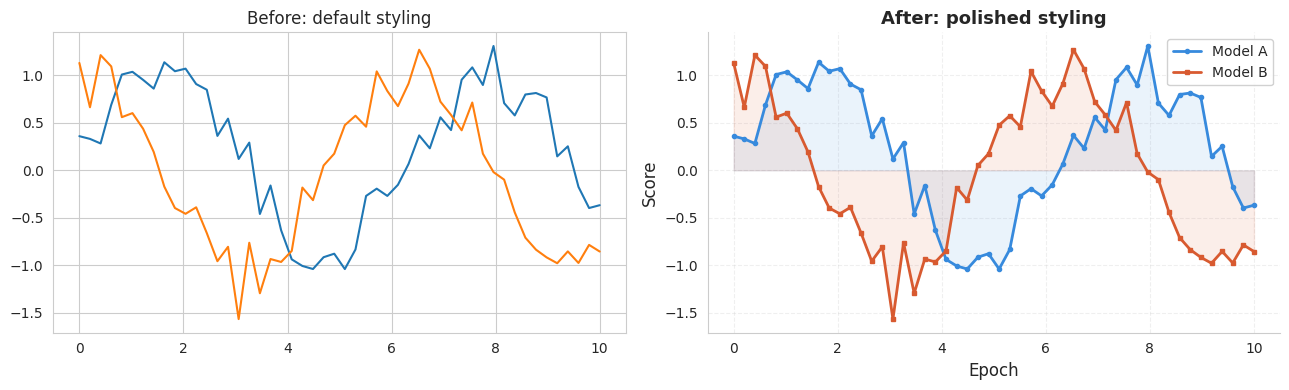

In [15]:
# A polished single plot vs a quick-and-dirty one
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = np.linspace(0, 10, 50)
y1 = np.sin(x) + np.random.randn(50) * 0.2
y2 = np.cos(x) + np.random.randn(50) * 0.2

# LEFT: Quick and dirty (what beginners make)
axes[0].plot(x, y1)
axes[0].plot(x, y2)
axes[0].set_title("Before: default styling")

# RIGHT: Polished (what you should aim for)
axes[1].plot(x, y1, color="#378ADD", linewidth=2, label="Model A", marker='o', markersize=3)
axes[1].plot(x, y2, color="#D85A30", linewidth=2, label="Model B", marker='s', markersize=3)
axes[1].fill_between(x, y1, alpha=0.1, color="#378ADD")
axes[1].fill_between(x, y2, alpha=0.1, color="#D85A30")
#fill_between(x, y_lower, y_upper)!
#Blue shade = area between the blue line and y=0, always present under the blue line
#Orange shade = area between the orange line and y=0, always present under the orange line
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Score", fontsize=12)
axes[1].set_title("After: polished styling", fontsize=13, fontweight='bold')
axes[1].legend(frameon=True, framealpha=0.9, fontsize=10)
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
# Saving figures — always use tight_layout and dpi
# fig.savefig("plot.png", dpi=150, bbox_inches='tight', facecolor='white')
# fig.savefig("plot.pdf", bbox_inches='tight')  # vector format for papers

# Useful rcParams to set at the top of any notebook
# import matplotlib
# matplotlib.rcParams['figure.figsize'] = (10, 5)
# matplotlib.rcParams['figure.dpi'] = 100
# matplotlib.rcParams['font.size'] = 12
# matplotlib.rcParams['axes.spines.top'] = False
# matplotlib.rcParams['axes.spines.right'] = False

print("Tip: Set rcParams once at the top of your notebook, and all plots inherit the style.")

Tip: Set rcParams once at the top of your notebook, and all plots inherit the style.


### Seaborn `FacetGrid` — small multiples

When you want the same plot for each category side by side. Very useful for comparing groups.

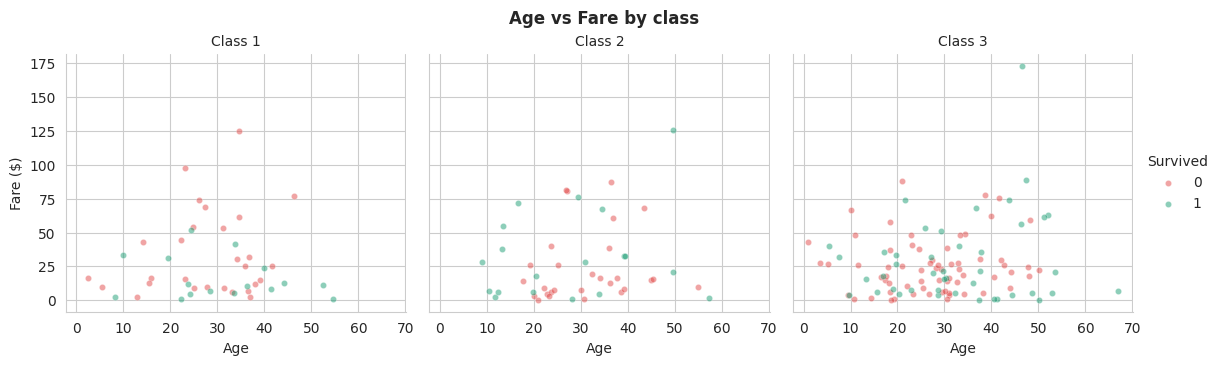

In [14]:
# FacetGrid: one scatter per passenger class
g = sns.FacetGrid(titanic, col="pclass", hue="survived",
                  palette=["#E24B4A", "#1D9E75"], height=3.5, aspect=1.1)
g.map_dataframe(sns.scatterplot, x="age", y="fare", alpha=0.5, s=20)
g.add_legend(title="Survived")
g.set_titles("Class {col_name}")
g.set_axis_labels("Age", "Fare ($)")
g.figure.suptitle("Age vs Fare by class", y=1.03, fontweight='bold')
plt.show()

---
## Summary of extra topics covered

**Python:**
- f-strings with formatting (`.2f`, `.1%`, `04d`, `!r`)
- String methods for file handling (`.strip()`, `.lower()`, `.endswith()`)
- Error handling with `try`/`except` and `raise`

**NumPy:**
- dtypes: `float64` vs `float32` vs `float16` — memory and GPU implications
- Views vs copies — when slicing shares memory and when it doesn't
- `keepdims=True` — the key to correct broadcasting in row/column operations
- Numerically stable softmax pattern
- Common one-liner patterns cheat sheet

**Pandas:**
- `.loc` (label-based) vs `.iloc` (position-based) selection
- `pd.read_csv` options: `usecols`, `dtype`, `na_values`, `nrows`
- `.apply()` (element/row/column), `.map()` (dict-based), `pd.cut()` / `pd.qcut()` (binning)
- `pd.crosstab()` for frequency tables

**Visualisation:**
- Chart type decision guide
- Polished styling: colors, `fill_between`, spine removal, grid, `rcParams`
- Saving figures with proper DPI
- Seaborn `FacetGrid` for small multiples

These topics complement the main notebook. Together they give you a complete 2 × 2-hour class.